# 04 - Explore and Baseline

This notebook performs exploratory data analysis and establishes baseline regression models for CO₂ uptake prediction.

The analysis includes:
- Feature and target distributions
- Correlation analysis
- Feature-target relationships
- Baseline regression models
- Model evaluation using regression metrics

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "Processed_527_datapoints.csv"

df = pd.read_csv(RAW_DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (527, 11)


In [2]:
TARGET_COLUMN = "CO2 uptake (mmol/g)"

FEATURE_COLUMNS = [
    "Surface Area (m2/g)",
    "Total Pore Volume(cm3/g)",
    "Micropore Volume (cm3/g)",
    "C (%)",
    "H (%)",
    "N (%)",
    "O (%)",
    "S (%)",
    "Temp (°C)",
    "Pressure (bar)"
]

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

print("Number of features:", len(FEATURE_COLUMNS))
print("Target:", TARGET_COLUMN)

Number of features: 10
Target: CO2 uptake (mmol/g)


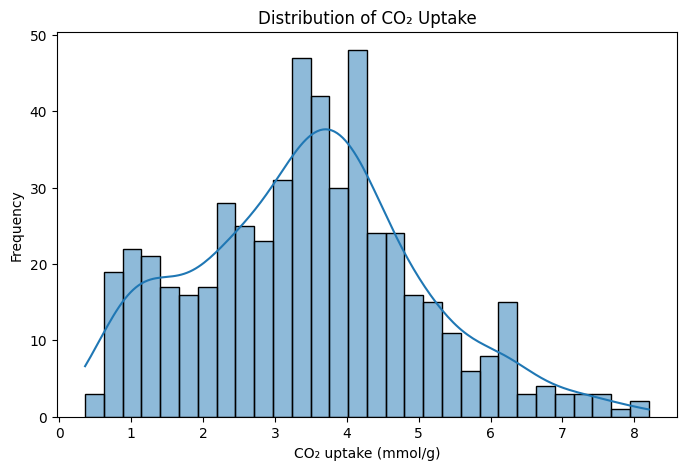

In [3]:
plt.figure(figsize=(8, 5))

sns.histplot(
    y,
    bins=30,
    kde=True
)

plt.xlabel("CO₂ uptake (mmol/g)")
plt.ylabel("Frequency")
plt.title("Distribution of CO₂ Uptake")

plt.show()

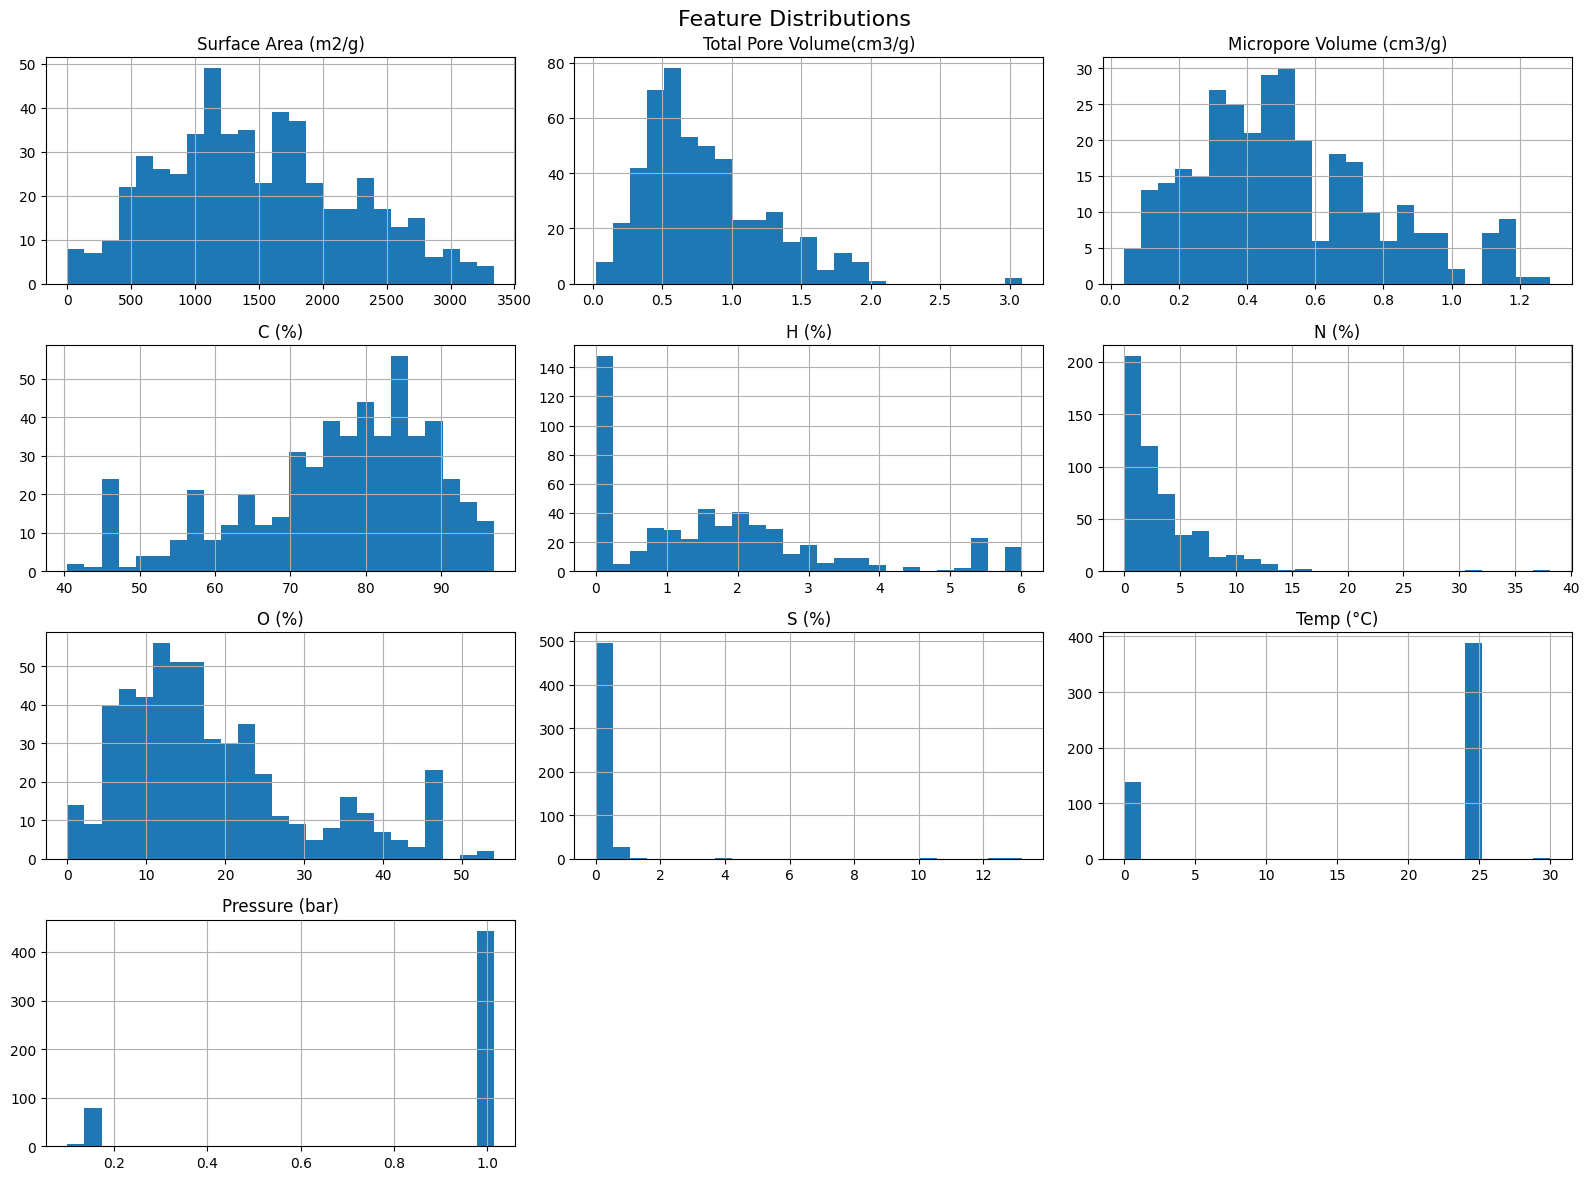

In [4]:
X.hist(
    figsize=(16, 12),
    bins=25
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

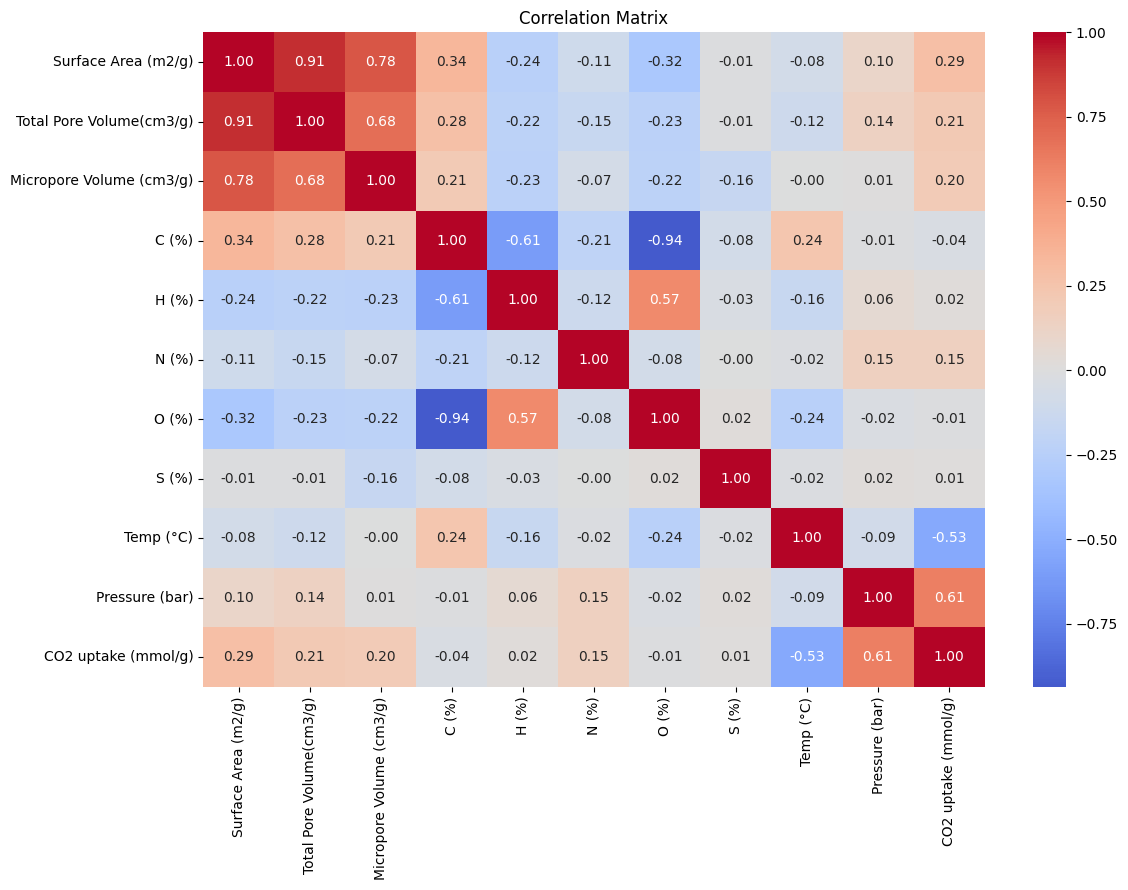

In [5]:
correlation_matrix = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

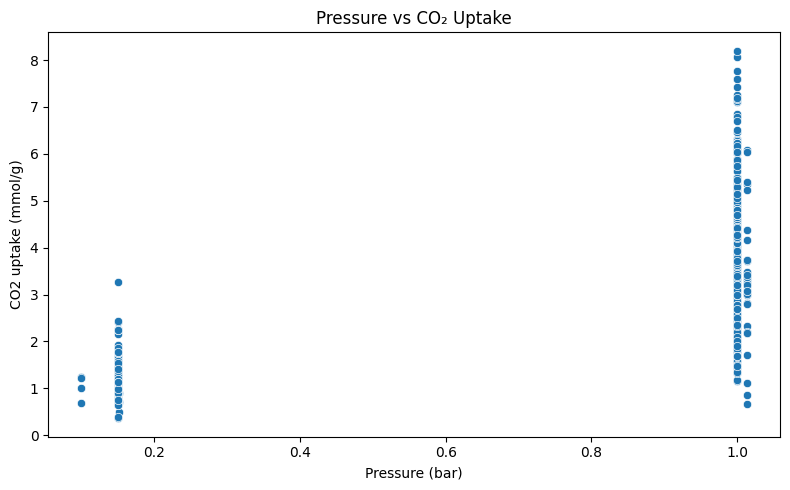

In [6]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Pressure (bar)",
    y=TARGET_COLUMN
)

plt.title("Pressure vs CO₂ Uptake")
plt.tight_layout()
plt.show()

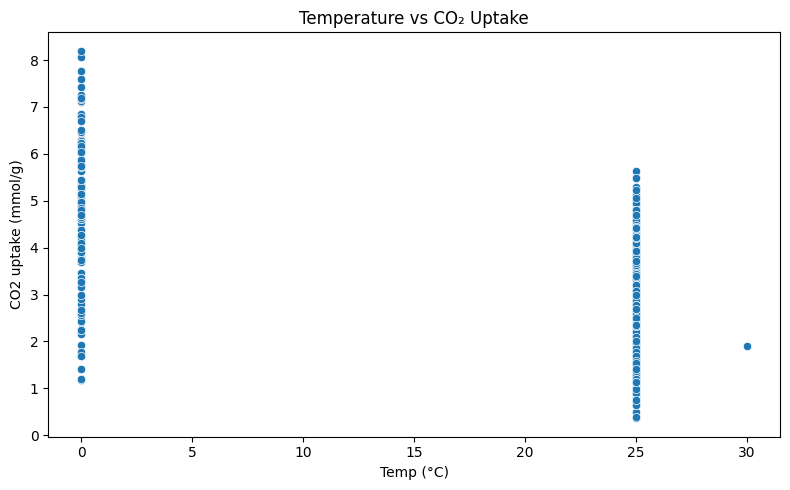

In [7]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Temp (°C)",
    y=TARGET_COLUMN
)

plt.title("Temperature vs CO₂ Uptake")
plt.tight_layout()
plt.show()

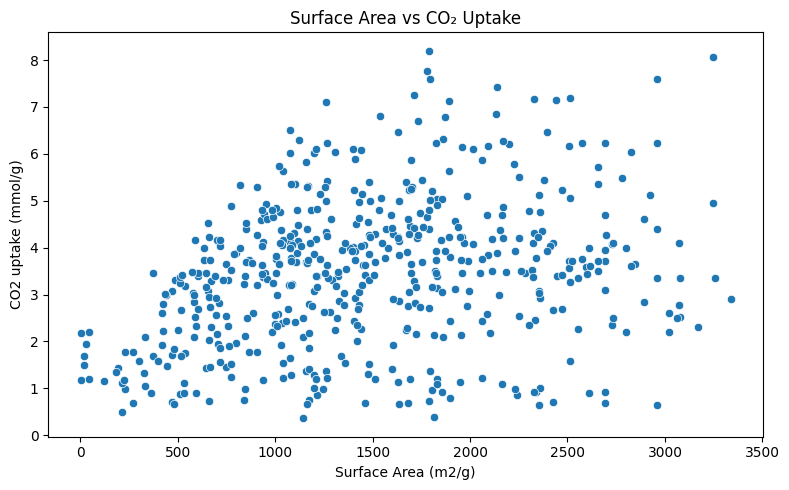

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Surface Area (m2/g)",
    y=TARGET_COLUMN
)

plt.title("Surface Area vs CO₂ Uptake")
plt.tight_layout()
plt.show()

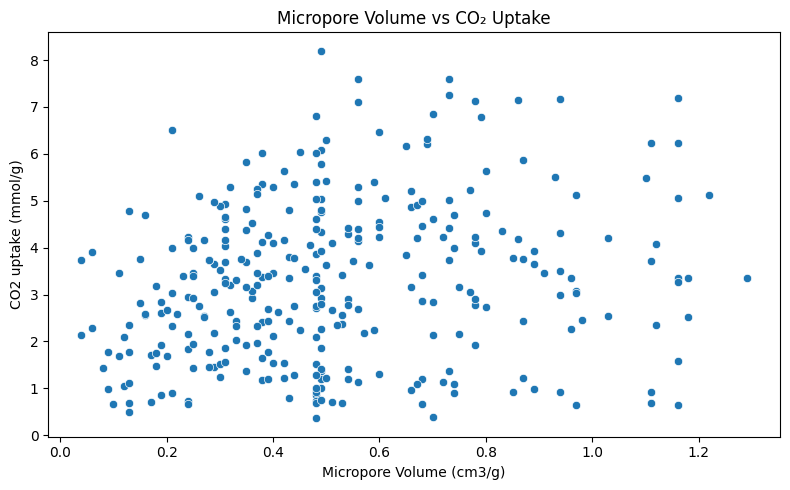

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Micropore Volume (cm3/g)",
    y=TARGET_COLUMN
)

plt.title("Micropore Volume vs CO₂ Uptake")
plt.tight_layout()
plt.show()

In [11]:
def evaluate_regression_model(model_name, model, X_train, y_train, X_eval, y_eval):
    model.fit(X_train, y_train)

    predictions = model.predict(X_eval)

    mae = mean_absolute_error(y_eval, predictions)
    rmse = np.sqrt(mean_squared_error(y_eval, predictions))
    r2 = r2_score(y_eval, predictions)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [12]:
dummy_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyRegressor(strategy="mean"))
])

In [13]:
SPLIT_PATH = PROJECT_ROOT / "artifacts" / "splits" / "split_assignments.csv"

split_assignments = pd.read_csv(SPLIT_PATH)

split_assignments.head()

,row_id,split
0,0,test
1,1,validation
2,2,test
3,3,train
4,4,train


In [16]:
df_model = df.drop_duplicates().copy()
df_model.insert(0, "row_id", range(len(df_model)))

train_ids = split_assignments.loc[
    split_assignments["split"] == "train",
    "row_id"
]

val_ids = split_assignments.loc[
    split_assignments["split"] == "validation",
    "row_id"
]

test_ids = split_assignments.loc[
    split_assignments["split"] == "test",
    "row_id"
]

train_data = df_model[df_model["row_id"].isin(train_ids)]
val_data = df_model[df_model["row_id"].isin(val_ids)]
test_data = df_model[df_model["row_id"].isin(test_ids)]

X_train = train_data[FEATURE_COLUMNS]
y_train = train_data[TARGET_COLUMN]

X_val = val_data[FEATURE_COLUMNS]
y_val = val_data[TARGET_COLUMN]

X_test = test_data[FEATURE_COLUMNS]
y_test = test_data[TARGET_COLUMN]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (336, 10)
Validation: (84, 10)
Test: (106, 10)


In [17]:
dummy_results = evaluate_regression_model(
    "DummyRegressor",
    dummy_model,
    X_train,
    y_train,
    X_val,
    y_val
)

dummy_results

{'Model': 'DummyRegressor',
 'MAE': 1.235768060064935,
 'RMSE': np.float64(1.5276676094079007),
 'R2': -0.029219256755279588}

In [18]:
ridge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

In [19]:
ridge_results = evaluate_regression_model(
    "Ridge",
    ridge_model,
    X_train,
    y_train,
    X_val,
    y_val
)

ridge_results

{'Model': 'Ridge',
 'MAE': 0.6630003403290561,
 'RMSE': np.float64(0.90126419365804),
 'R2': 0.6417762327211957}

In [20]:
baseline_results = pd.DataFrame([
    dummy_results,
    ridge_results
])

baseline_results

,Model,MAE,RMSE,R2
0,DummyRegressor,1.235768,1.527668,-0.029219
1,Ridge,0.663000,0.901264,0.641776


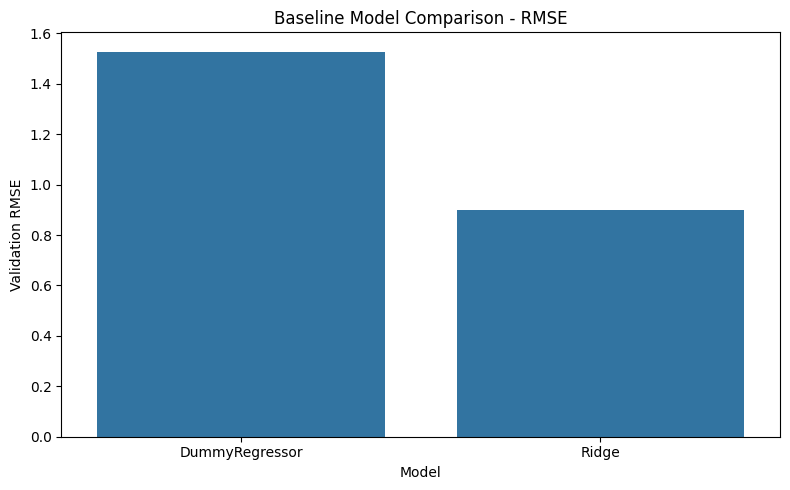

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=baseline_results,
    x="Model",
    y="RMSE"
)

plt.ylabel("Validation RMSE")
plt.xlabel("Model")
plt.title("Baseline Model Comparison - RMSE")
plt.tight_layout()
plt.show()

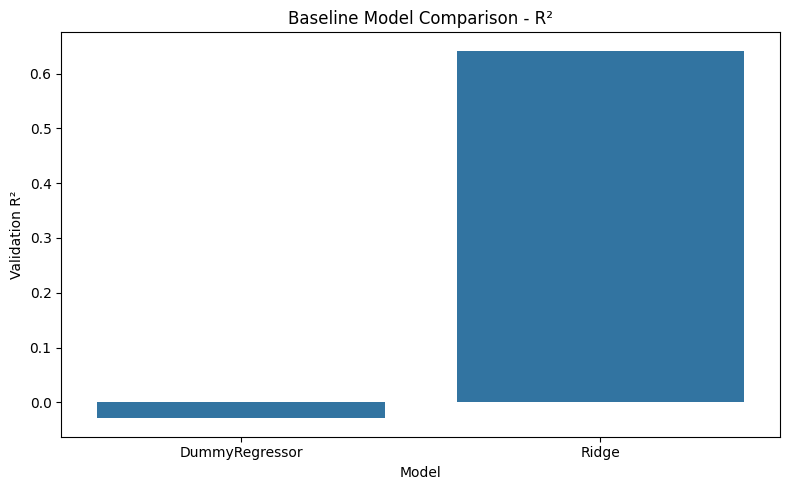

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=baseline_results,
    x="Model",
    y="R2"
)

plt.ylabel("Validation R²")
plt.xlabel("Model")
plt.title("Baseline Model Comparison - R²")
plt.tight_layout()
plt.show()


In [23]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [24]:
baseline_results_path = RESULTS_DIR / "baseline_results.csv"

baseline_results.to_csv(
    baseline_results_path,
    index=False
)

print("Baseline results saved to:")
print(baseline_results_path)

Baseline results saved to:
/Users/divyakandlakuti/interpretable-co2-adsorption-ml/results/baseline_results.csv


## Baseline Findings

The DummyRegressor establishes a simple reference point by predicting the mean CO₂ uptake of the training data.

Ridge Regression provides a substantially stronger baseline. On the validation set, Ridge achieved lower MAE and RMSE and a substantially higher R² than the DummyRegressor.

This indicates that the selected input features contain meaningful predictive information about CO₂ uptake, even for a regularized linear model.

More complex nonlinear models will therefore be evaluated to determine whether they provide further improvement over the Ridge baseline.